In [2]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code


In [3]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)

In [3]:
# other imports
import numpy as np
from importlib import reload

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [29]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

maze order: 1
Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       135          Method:                  ML          
No. Groups:             15           Scale:                   259.5240    
Min. group size:        9            Log-Likelihood:          -582.9639   
Max. group size:        9            Converged:               Yes         
Mean group size:        9.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      26.569    6.686  3.974 0.000  13.464 39.675
condition[T.opto]              -3.887    9.788 -0.397 0.691 -23.071 15.297
day_on_maze                     8.667    0.735 11.786 0.000   7.225 10.108
condition[T.op

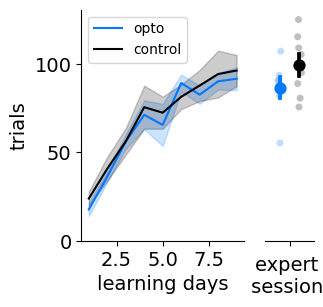

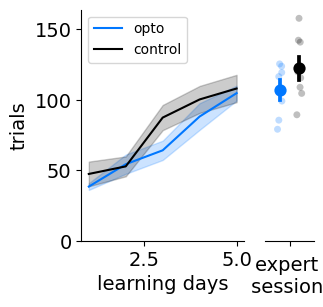

In [30]:
reload(bl)
for maze_order in [1, 2]:
    print(f"maze order: {maze_order}")
    fig, axes = plt.subplots(1, 2, figsize=(3, 3), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=True, axes=axes)
    # fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [49]:
from GridMaze.analysis.behaviour import performance_metrics as pm

performance_df = pm.get_performance_df()

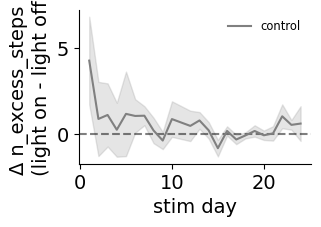

In [10]:
reload(pm)
f, ax = plt.subplots(1, 1, figsize=(3, 2))
pm.plot_stim_effects_over_days(
    performance_df,
    y="n_excess_steps",
    groups=["control"],
    rolling_avg=False,
    ax=ax,
)

Mixed ANOVA: trial_duration
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |          F |    p-unc |         np2 |   eps |
|-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------|
| condition   | 24.5156     |     1 |    13 | 24.5156     | 1.25059    | 0.283679 | 0.0877573   |   nan |
| stim_trial  |  0.00136272 |     1 |    13 |  0.00136272 | 0.00112905 | 0.973705 | 8.68425e-05 |     1 |
| Interaction |  1.89795    |     1 |    13 |  1.89795    | 1.5725     | 0.231925 | 0.107909    |   nan |
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
Mixed ANOVA: n_errors
+-------------+-------------+-------+-------+-------------+------------+----------+-------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |          F |    p-unc |         np2 |   ep

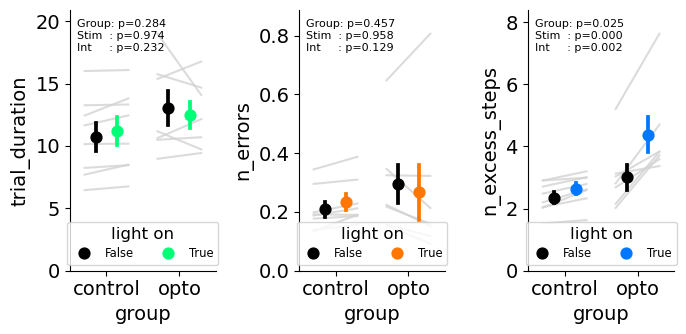

In [50]:
reload(pm)
from GridMaze.analysis.core import plotting as cp

reload(cp)

stim_day_range = (6, np.inf)

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
for y, ax, ot, color in zip(
    ["trial_duration", "n_errors", "n_excess_steps"],
    axes,
    [3 * 60, 15, 500],  # roughly 99.5th percentiles
    ["#00FF77", "#FF7700", "#0077FF"],
):
    pm.plot_random_effects_summary(
        performance_df,
        y=y,
        stim_day_range=stim_day_range,
        outlier_thres=ot,
        print_stats=True,
        stim_color=color,
        ax=ax,
    )
fig.tight_layout()

### Example trajectory plots

In [ ]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

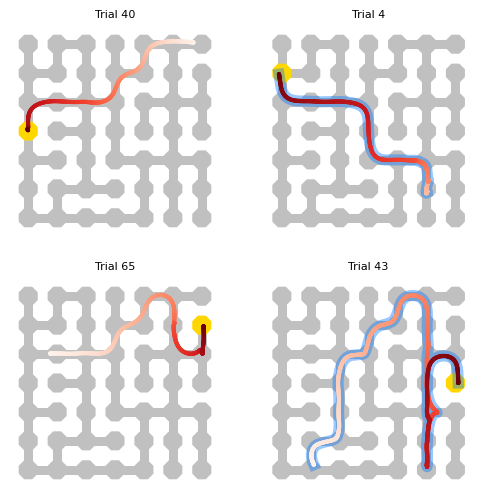

In [ ]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
# f.savefig("../results/figures/opto_trajectory_examples.pdf")

In [22]:
session2 = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17])[0]

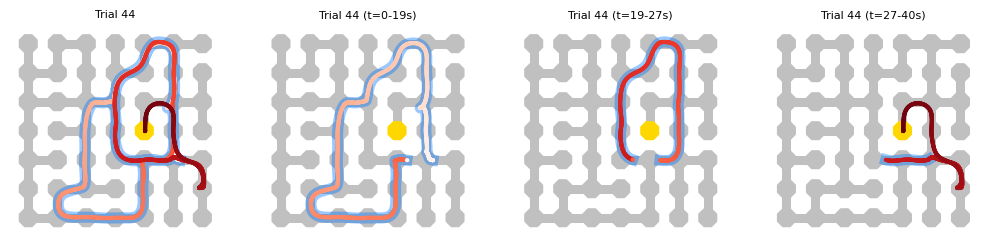

In [ ]:
# another example disrupted nav trial in opto subject
reload(tp)
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session2, trial=trial, t_range=t_range, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples2.pdf")

### Does mFC inhibition impair early navigation?

In [51]:
from GridMaze.analysis.behaviour import distance_to_goal as dtg

ddtg_df = dtg.get_delta_distance_to_goal_df()
curve_fit_results = dtg.get_ddtg_curve_fit_df(ddtg_df, stim_day_range=(6, np.inf))

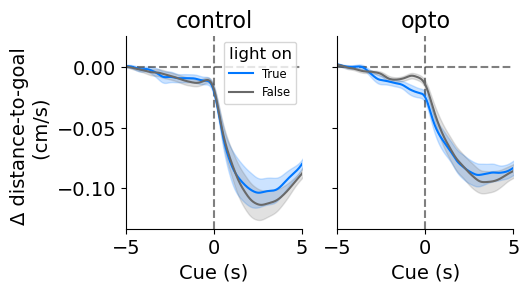

In [57]:
reload(dtg)
f, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)
dtg.plot_delta_distance_to_goal_summary(ddtg_df, axes=axes)

Mixed ANOVA: amplitude
+-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |    p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------|
| condition   | 0.0013248   |     1 |    13 | 0.0013248   | 0.778562 | 0.393605 | 0.0565053 |   nan |
| stim_trial  | 0.00193846  |     1 |    13 | 0.00193846  | 8.90566  | 0.010554 | 0.406546  |     1 |
| Interaction | 0.000102329 |     1 |    13 | 0.000102329 | 0.470121 | 0.504976 | 0.034901  |   nan |
+-------------+-------------+-------+-------+-------------+----------+----------+-----------+-------+
Mixed ANOVA: lambda
+-------------+-----------+-------+-------+-----------+----------+-----------+-----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |     p-unc |       np2 |   eps |
|-------------+-----------+-------+-------+--

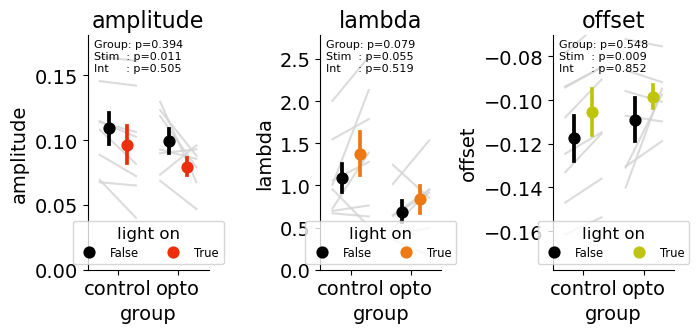

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
dtg.plot_curve_fit_random_effects_summary(curve_fit_results, print_stats=True, axes=axes)
fig.tight_layout()

prelim conclusion: no obvious differences at the start of the trial, mFC less important here

### Is the group x stim effect equally strong on all trials or does it interact with maze structure / starting distance to goal, etc.

In [4]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = pm.get_performance_df()

### Additional excess steps in the opto group is not evenly spread across navigational goals...

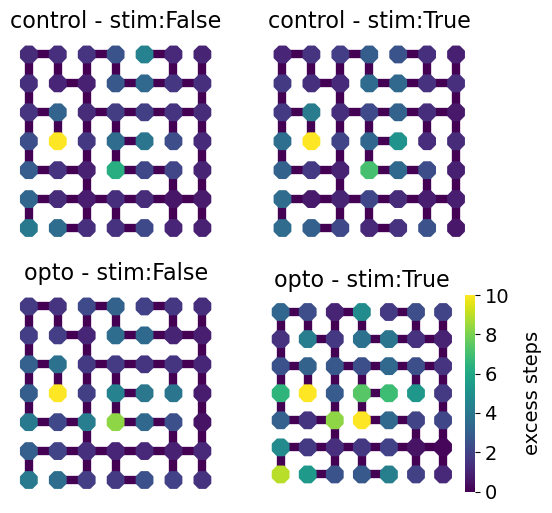

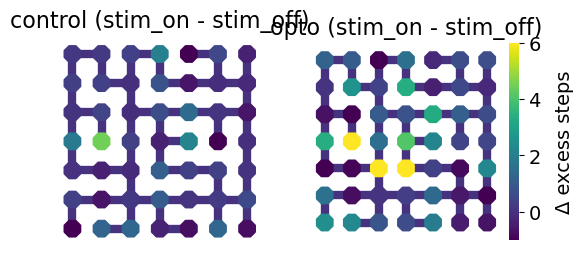

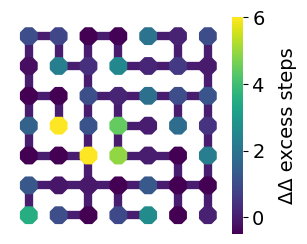

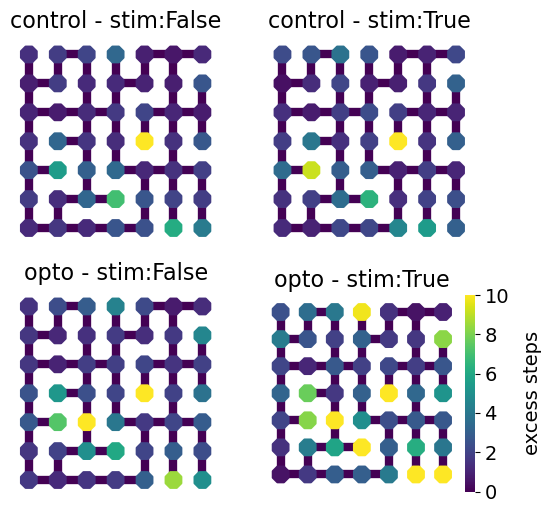

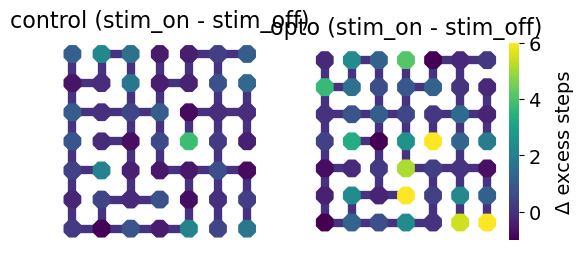

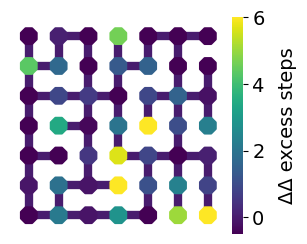

In [10]:
reload(es)
for maze in ["maze_1", "maze_2"]:
    for pa, v_range in zip(["raw", "delta", "delta_delta"], [(None, 10), (-1, 6), (-0.5, 6)]):
        es.plot_excess_steps_by_goal_heatmap_summary(
            excess_steps_df,
            outlier_thres=250,
            maze_name=maze,
            vmin=v_range[0],
            vmax=v_range[1],
            plot_as=pa,
            colormap="viridis",
        )

#### Indeed, trials with goals with higher fitness* have stim-induced performance deficits in the opto group
*term borrowed from how we design the mazes: decorrelation between eucldiean and geodesic distances across all pairs of points including a given goal

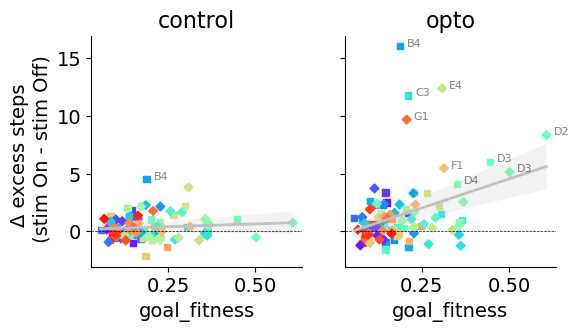

In [11]:
reload(es)
f, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True, sharex=True)
es.plot_stratified_delta_excess_steps(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=500,
    var="goal_fitness",
    axes=axes,
)

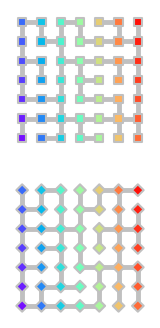

In [56]:
f, axes = plt.subplots(2, 1, figsize=(2, 4))
es.plot_special_maze_legend(axes=axes)

#### we can get a random effects measure on the strength of this effect by comparing the slopes across opto and control conditions

T-tests on slope from delta xs steps linear fit:
  control vs opto: t=-2.70, p=0.018
  control vs 0: t=0.63, p=0.549
  opto vs 0: t=3.19, p=0.019


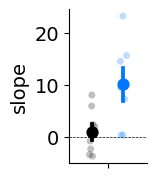

In [45]:
f, ax = plt.subplots(1, 1, figsize=(1, 2))
es.plot_delta_excess_steps_fit_slopes(
    excess_steps_df, stim_day_range=(6, np.inf), outlier_thres=500, var="goal_fitness", print_stats=True, ax=ax
)

#### another way to look at this effect is with a comparison linear mixed models, modelling n_excess_steps across trials to test for a specific group x stim x goal_fitness interaction

In [46]:
es.run_3way_linear_mixed_model(
    excess_steps_df,
    stim_day_range=(6, np.inf),
    outlier_thres=500,
    var="goal_fitness",
    zscore_var=True,
    print_stats_model_summaries=True,
)

Likelihood Ratio Test for group x stim x var interaction:
    LR=10.335, df=1, p=0.001306
Full model results:
                              Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             n_excess_steps
No. Observations:              29593               Method:                         ML            
No. Groups:                    15                  Scale:                          69.3264       
Min. group size:               1404                Log-Likelihood:                 -104735.1651  
Max. group size:               2665                Converged:                      Yes           
Mean group size:               1972.9                                                            
-------------------------------------------------------------------------------------------------
                                                         Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------

### What errors do subjects make?

In [ ]:
from GridMaze.analysis.errors import errors

error_df = errors.get_error_df()

Mixed ANOVA: error_rate
+-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |       p-unc |        np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------|
| condition   | 0.000247159 |     1 |    13 | 0.000247159 |  4.87596 | 0.0458059   | 0.272766   |   nan |
| stim_trial  | 0.000245427 |     1 |    13 | 0.000245427 | 18.2186  | 0.000915505 | 0.583581   |     1 |
| Interaction | 1.70614e-06 |     1 |    13 | 1.70614e-06 |  0.12665 | 0.727639    | 0.00964834 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-------------+------------+-------+
Mixed ANOVA: repeat_error_rate
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |      p-unc |      np2 |   eps

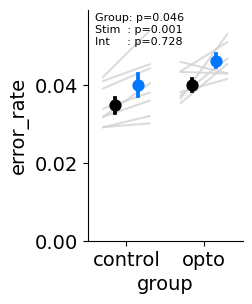

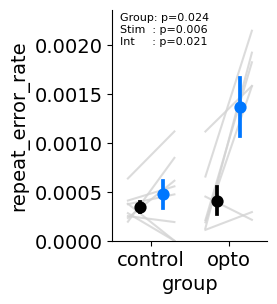

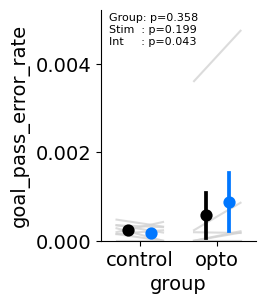

In [ ]:
for err_type in ["error", "repeat_error", "goal_pass_error"]:
    errors.plot_group_by_stim_errors(
        error_df,
        e=err_type,
    )

In [13]:
from GridMaze.analysis.errors import allocentric_error_maps as am

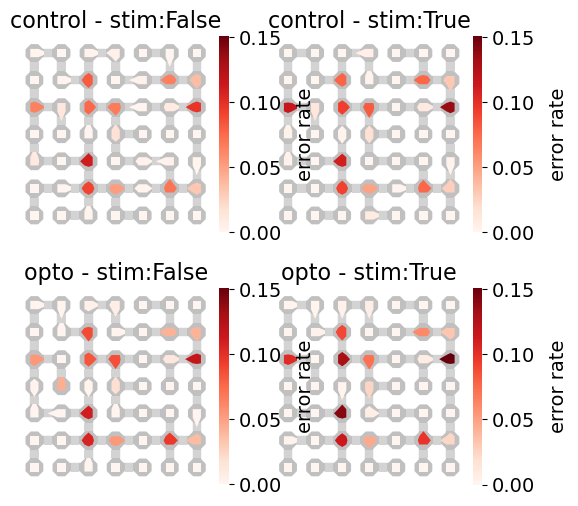

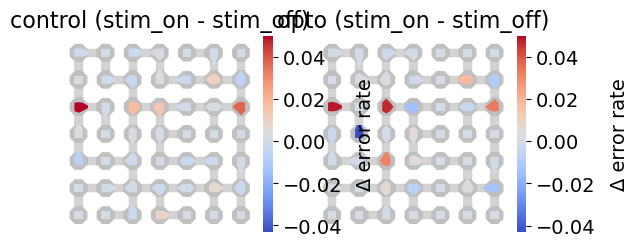

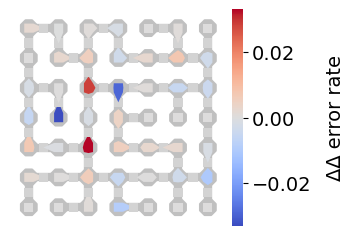

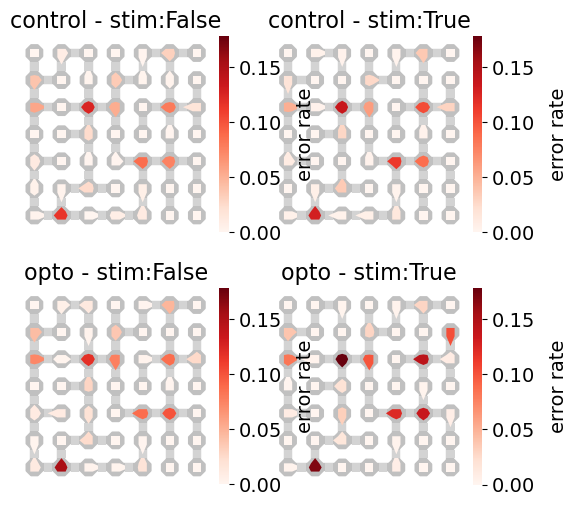

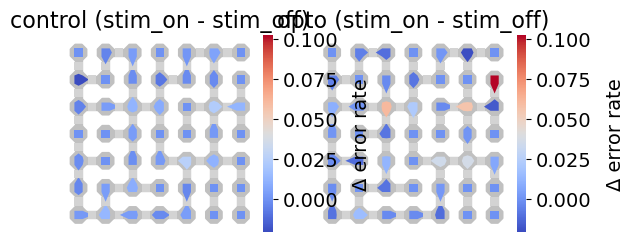

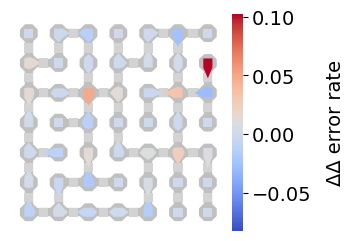

In [14]:
results_df = am.get_allocentric_error_maps_df(error_df, e="error")
for maze in ["maze_1", "maze_2"]:
    for plot_as, colormap in zip(["raw", "delta", "delta_delta"], ["Reds", "coolwarm", "coolwarm"]):
        am.plot_allocentric_error_map_summary(
            results_df,
            maze_name=maze,
            plot_as=plot_as,
            colormap=colormap,
        )

### What do these excess steps represent when mFC is inhibited on difficult trials?
Let's model subjects navigation choices during light ON and light OFF as a mixture of 4 strategies:
- vector navigation
- structure based navigation (optimal)
- habitual actions (what you usually do given recent histroy regardless of the goal)
- a backtracking penalty (mice don't like to turn around while moving)

In [4]:
from GridMaze.analysis.strategies import get_input_data as sd
from GridMaze.analysis.strategies import opto_effects as so

In [5]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
navigation_strategies_df = sd.get_navigation_strategies_df(
    strategies=strategies,
    n_history=1,
    verbose=False,
)

In [ ]:
results_df = so.get_group_by_stim_strategy_weights(
    navigation_strategies_df,
    strategies=strategies,
    stim_day_range=(6, gs.TOTAL_STIM_DAYS),
    max_trial_duration=None,
    stim_only=True,
)

Mixed ANOVA: vector
+-------------+------------+-------+-------+------------+----------+-----------+-----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |     p-unc |       np2 |   eps |
|-------------+------------+-------+-------+------------+----------+-----------+-----------+-------|
| condition   | 0.100625   |     1 |    13 | 0.100625   | 5.08269  | 0.0420578 | 0.281081  |   nan |
| stim_trial  | 0.0406774  |     1 |    13 | 0.0406774  | 6.74976  | 0.0220884 | 0.341764  |     1 |
| Interaction | 0.00129233 |     1 |    13 | 0.00129233 | 0.214442 | 0.650965  | 0.0162278 |   nan |
+-------------+------------+-------+-------+------------+----------+-----------+-----------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+---------+-----------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |       F |     p-unc |      np2 |   eps |
|-------------+------------+-------+-------+--------

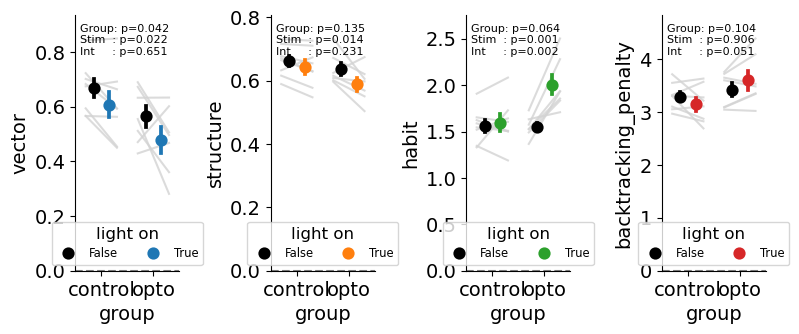

In [17]:
reload(so)
fig, axes = plt.subplots(1, len(strategies), figsize=(2 * len(strategies), 3.5))
so.plot_mixture_of_strategy_weights(results_df, axes=axes)
fig.tight_layout()

#### it looks like subjects become more habitual without mFC inhibition, potentially loosing their goal-directedness and relying on what the normally do given the immediate past